In [30]:
import pandas as pd
import seaborn as sns

In [31]:
columns = ["Sex", "Length", "Diam", "Height", "Whole", "Shucked", "Viscera", "Shell", "Rings"]
abalone = pd.read_csv('abalone.csv', names=columns)
abalone.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Sex      4177 non-null   object 
 1   Length   4177 non-null   float64
 2   Diam     4177 non-null   float64
 3   Height   4177 non-null   float64
 4   Whole    4177 non-null   float64
 5   Shucked  4177 non-null   float64
 6   Viscera  4177 non-null   float64
 7   Shell    4177 non-null   float64
 8   Rings    4177 non-null   int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 293.8+ KB


In [32]:
abalone['Sex'] = abalone['Sex'].astype('category')
abalone.describe(include='all')

,Sex,Length,Diam,Height,Whole,Shucked,Viscera,Shell,Rings
count,4177,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000
unique,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1528,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,0.523992,0.407881,0.139516,0.828742,0.359367,0.180594,0.238831,9.933684
std,NaN,0.120093,0.099240,0.041827,0.490389,0.221963,0.109614,0.139203,3.224169
min,NaN,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500,1.000000
25%,NaN,0.450000,0.350000,0.115000,0.441500,0.186000,0.093500,0.130000,8.000000
50%,NaN,0.545000,0.425000,0.140000,0.799500,0.336000,0.171000,0.234000,9.000000
75%,NaN,0.615000,0.480000,0.165000,1.153000,0.502000,0.253000,0.329000,11.000000


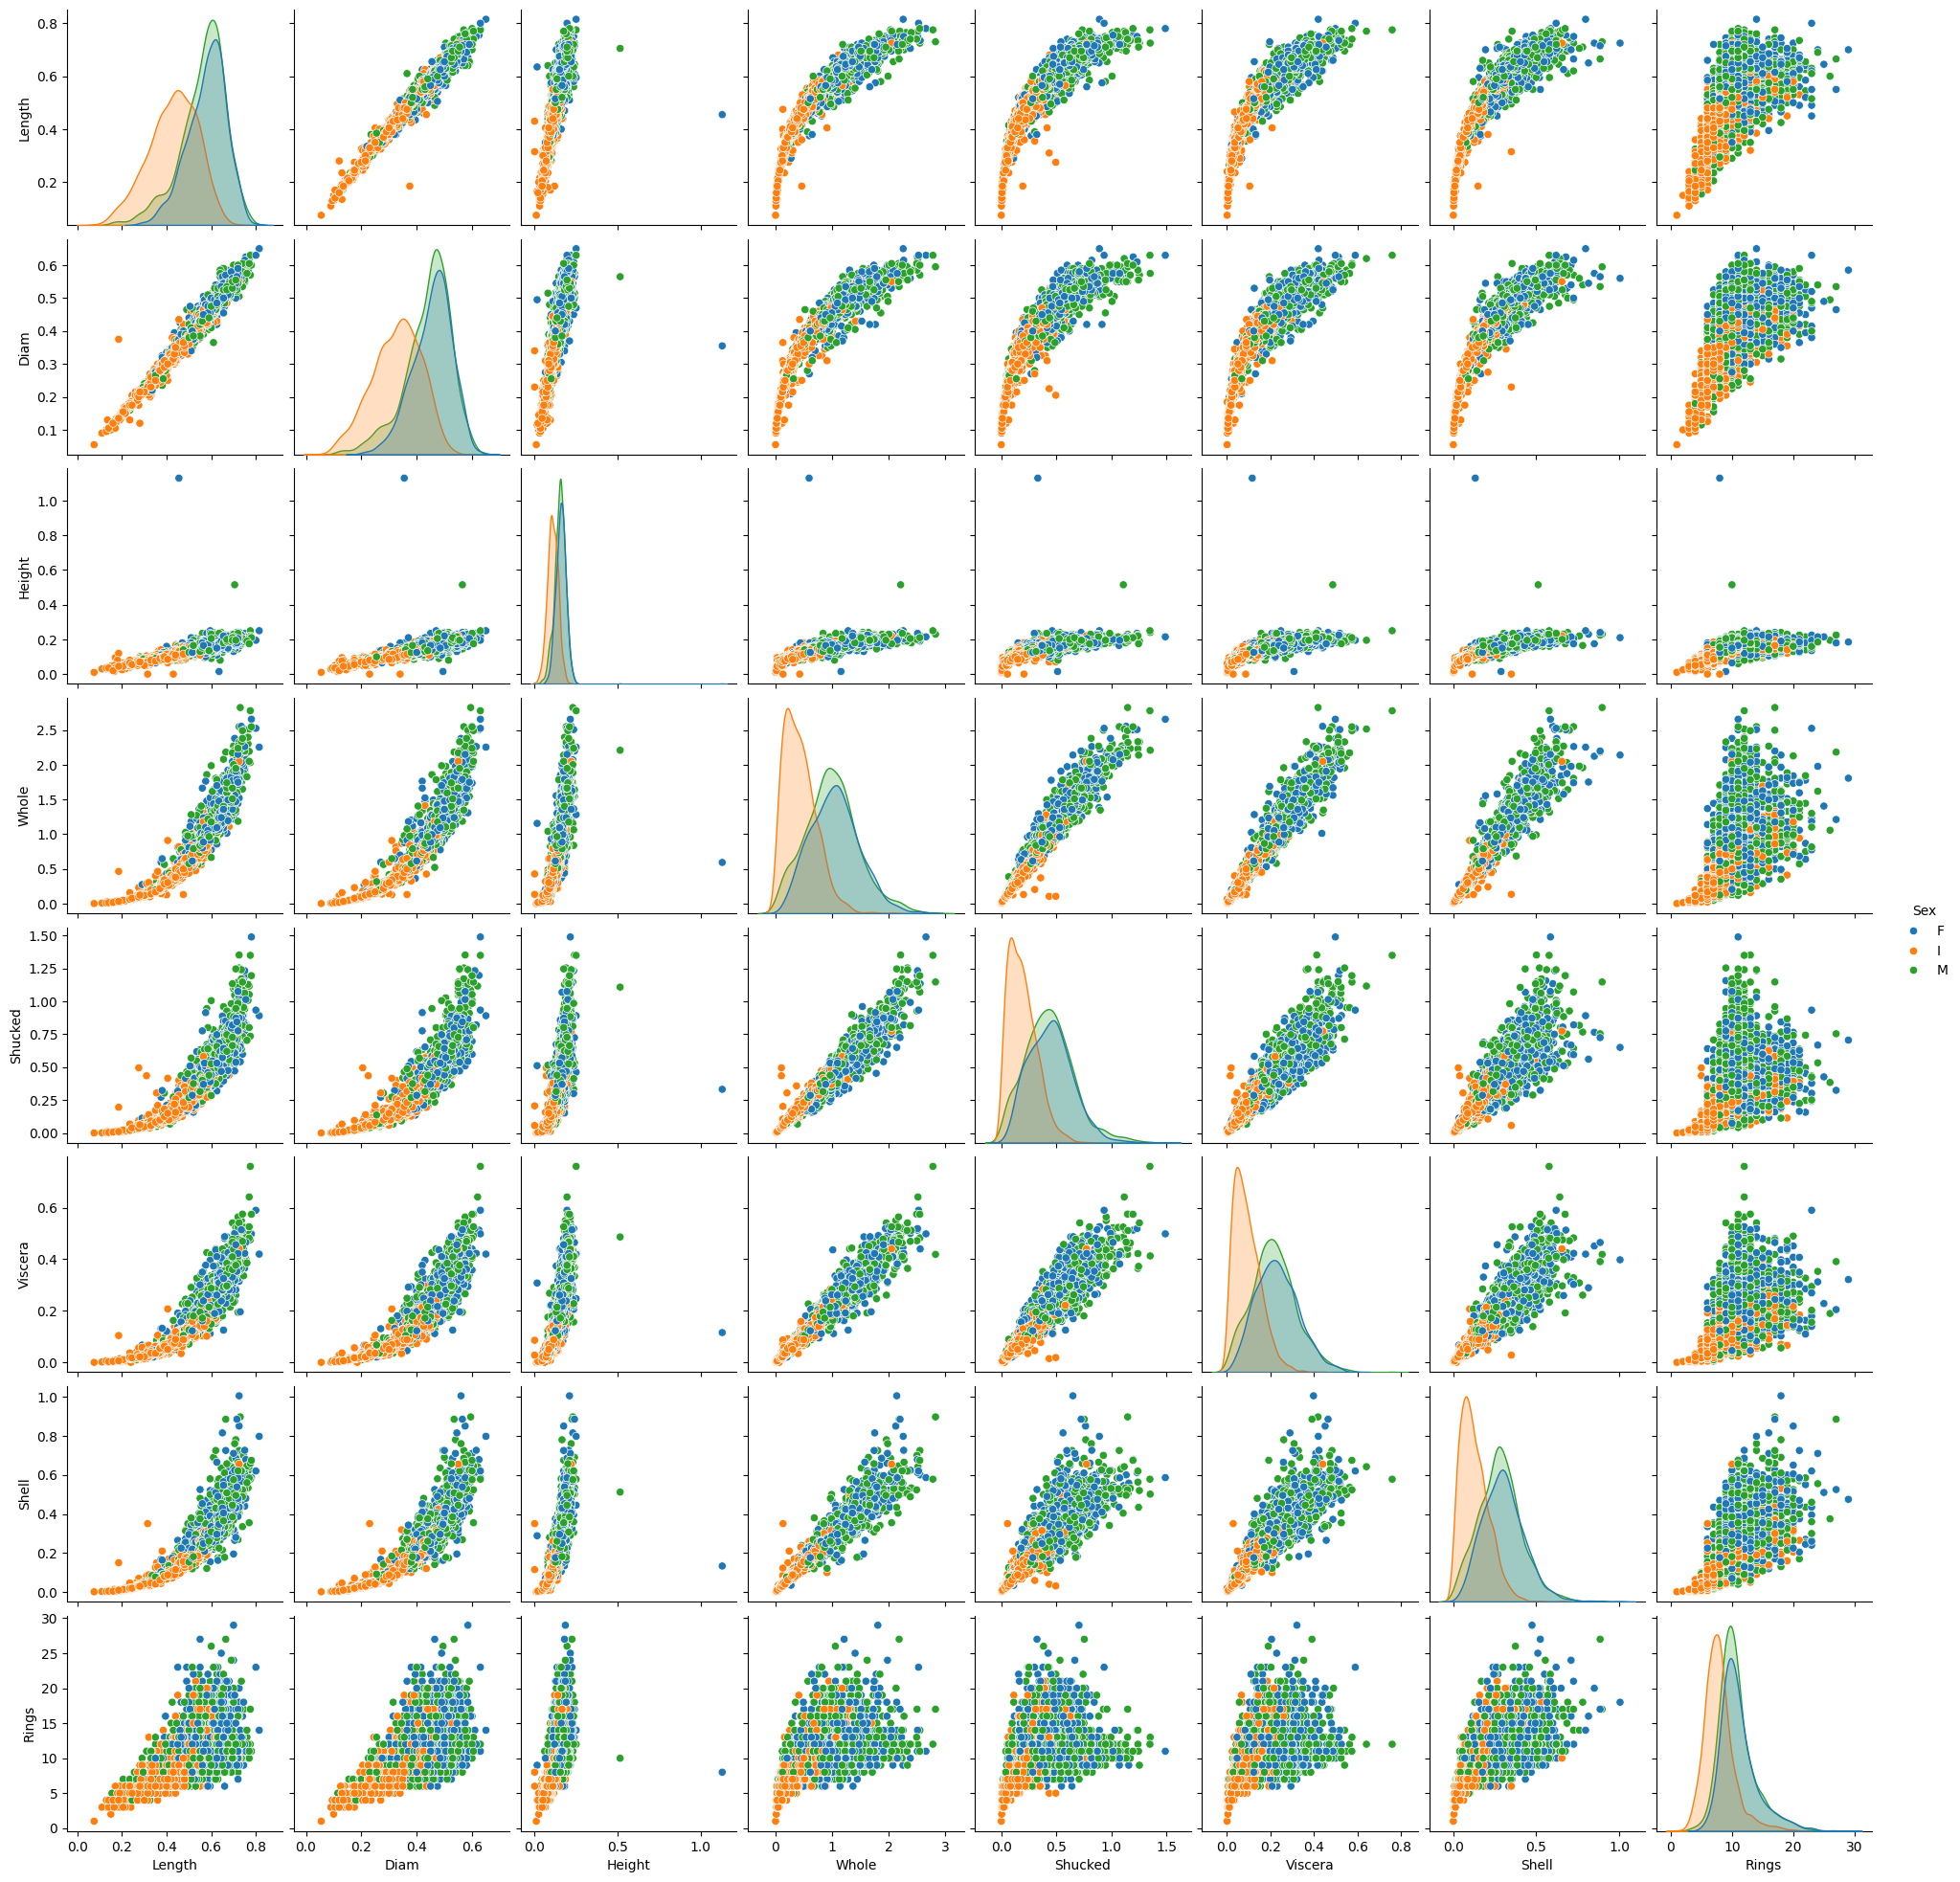

In [33]:
sns.pairplot(abalone, hue="Sex")

In [34]:
abalone['Sex'].value_counts()

Sex
M    1528
I    1342
F    1307
Name: count, dtype: int64

In [35]:
round(abalone['Sex'].value_counts(normalize=True) * 100)

Sex
M    37.0
I    32.0
F    31.0
Name: proportion, dtype: float64

L’ensemble de données des abalones est constitué de 4177 individus et de 9 variables, dont une catégorielle
(le sexe) et les autres numériques. Les données sont réparties de manière plutôt équilibrée suivant le sexe
(1307 femelles soit 31%, 1342 enfants soit 32% et 1528 mâles soit 37%). Les variables quantitatives prennent
des valeurs relativement petites, comprises entre 0 et 3, à l’exception de la variable Rings dont la plage de
valeurs va de 1 à 29.

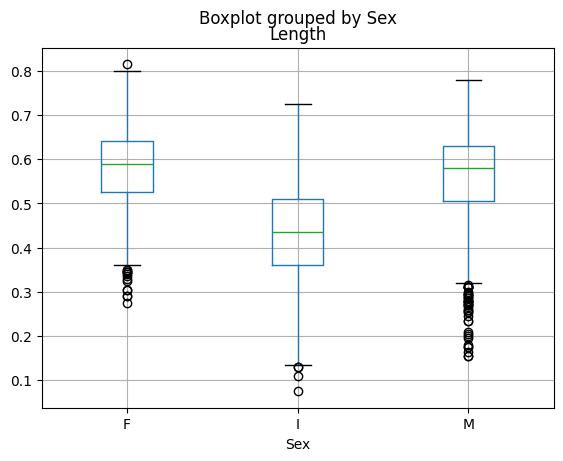

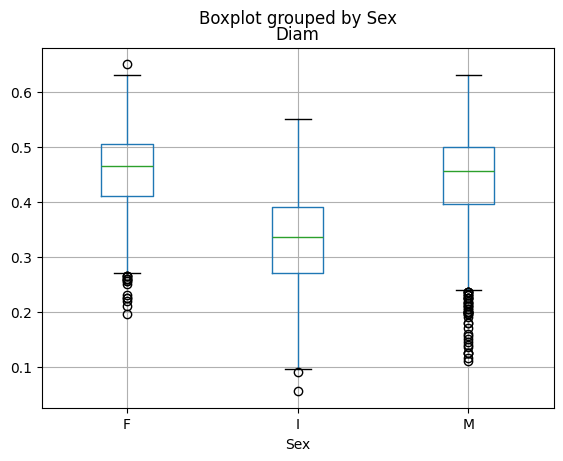

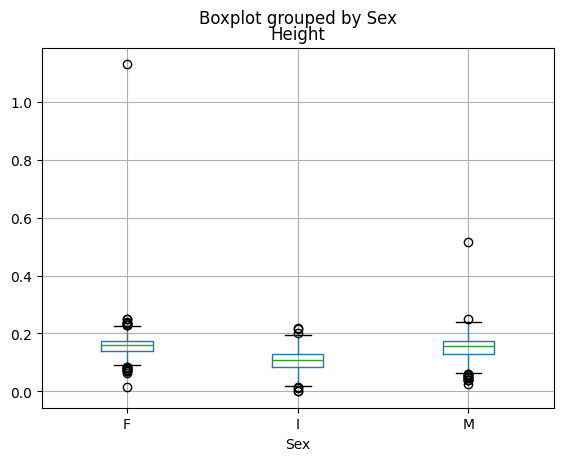

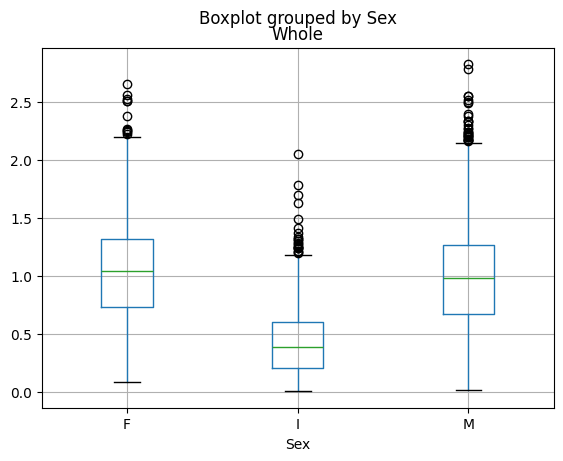

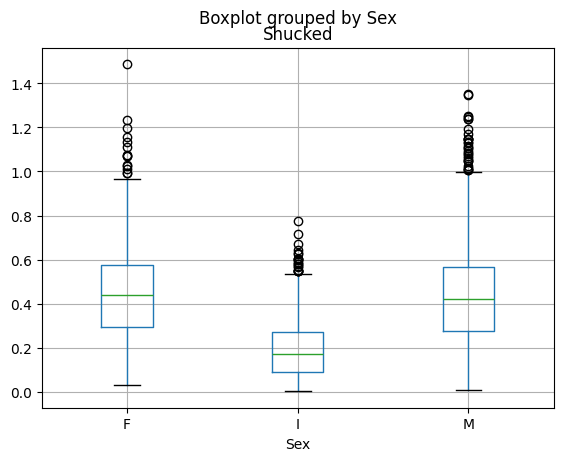

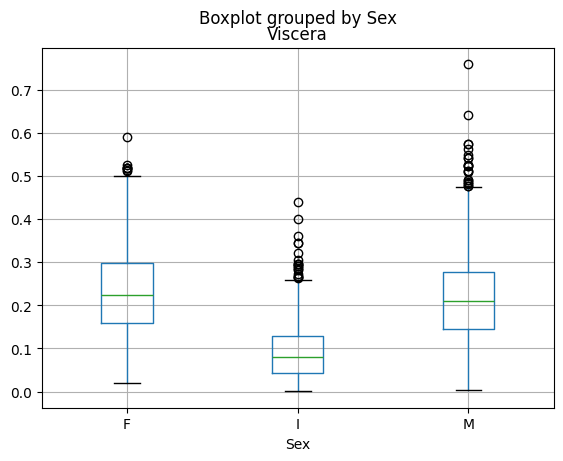

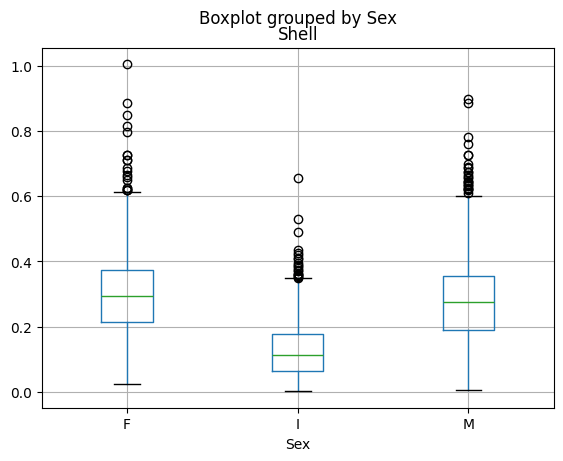

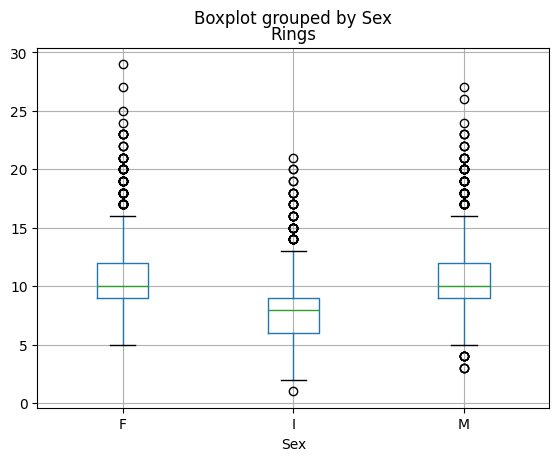

In [36]:
for col in columns[1:]:
    abalone.boxplot(column=col, by='Sex')

D’après ces boxplot, nous pouvons voir que les variables présentent une quantité non négligeable de valeurs
extrêmes en fonction du sexe.

In [37]:
abalone.corr(numeric_only=True)

,Length,Diam,Height,Whole,Shucked,Viscera,Shell,Rings
Length,1.000000,0.986812,0.827554,0.925261,0.897914,0.903018,0.897706,0.556720
Diam,0.986812,1.000000,0.833684,0.925452,0.893162,0.899724,0.905330,0.574660
Height,0.827554,0.833684,1.000000,0.819221,0.774972,0.798319,0.817338,0.557467
Whole,0.925261,0.925452,0.819221,1.000000,0.969405,0.966375,0.955355,0.540390
Shucked,0.897914,0.893162,0.774972,0.969405,1.000000,0.931961,0.882617,0.420884
Viscera,0.903018,0.899724,0.798319,0.966375,0.931961,1.000000,0.907656,0.503819
Shell,0.897706,0.905330,0.817338,0.955355,0.882617,0.907656,1.000000,0.627574
Rings,0.556720,0.574660,0.557467,0.540390,0.420884,0.503819,0.627574,1.000000


In [38]:
import plotly.express as px
df = px.data.iris()
fig = px.scatter_matrix(df)
fig.show()

Exception: Unable to read 'iris' dataset due to: [Errno 2] No such file or directory: 'c:\\Data\\projets\\random-machine-learning\\.venv\\Lib\\site-packages\\plotly\\package_data\\datasets\\iris.csv.gz'

Ici, nous pouvons voir que la variable Rings, à expliquer en fonction des variables physiologiques, est plutôt faiblement correlée linéairement avec ces dernières. Par ailleurs, les variables physiologiques sont fortement correlées linéairement entre elles. Ceci peut constituer un problème pour la prédiction de l’âge (Âge = Rings + 1.5) en fonction des variables physiologiques, dû à une potentielle multicollinéarité des variables explicatives.